# Lab 5 Instructions

In this lab, we will strenghten our knowledge on Python generators and SimPy environment by creating a variable bit rate (VBR) packet generator model (these kinds of models are widely used for modeling the behaviour of video conferencing participants). We will keep the model very simple (they can get quite complex though!).

VBR stands for Variable Bit Rate, which is a method used for encoding data where the bitrate (the number of bits used per unit of time to represent a continuous media stream) varies over time. In contrast to Constant Bit Rate (CBR), where the bitrate remains constant, VBR adjusts the bitrate dynamically according to the complexity of the content being encoded.

In VBR encoding, the bitrate may increase or decrease depending on the level of detail or motion in the media content. For example, during scenes with high complexity or motion, more bits may be allocated to accurately represent the details, resulting in a higher bitrate. Conversely, during simpler scenes with less motion, fewer bits may be needed, leading to a lower bitrate. This flexibility allows for more efficient use of bandwidth and storage space while maintaining the quality of the encoded content.

VBR encoding is commonly used in multimedia applications such as video streaming, audio encoding (e.g., MP3), and video compression standards (e.g., MPEG). It provides a balance between quality and file size, ensuring optimal viewing or listening experience while minimizing the data transfer or storage requirements. However, VBR encoding may introduce challenges in real-time applications due to the variable nature of the bitrate, requiring careful consideration of buffering and network bandwidth management. 

VBR combined with statistical multiplexing allows multiple bursty data streams such as video encoders whose bit rate fluctuates with scene complexity to efficiently share the same channel capacity. Instead of allocating each stream a fixed peak bandwidth (as in CBR), statistical multiplexing takes advantage of the fact that peaks from different sources rarely occur at the same time, enabling a “pooling gain” where unused capacity from one source can be dynamically used by another. This leads to better bandwidth efficiency, more consistent overall visual quality, and improved channel utilization, since simple scenes consume fewer bits while complex scenes are supported without requiring each stream to be permanently provisioned at its maximum rate.

## 1. Bursty Traffic Generator function

This code builds on Lab4 to simulate bursty traffic patterns with alternating idle and active periods (deterministic). During each iteration of the generator, it prints the current time, simulating the entry into either an idle or an active period.

In the idle period, the duration is randomly generated from a normal distribution with your input of  mean  and a standard deviation. After waiting for the idle duration, the generator moves to the active period.

### 1.1 Exercise 

## Bursty Traffic Generator – Exercise Questions


1. In the code below, alternating random active and idle durations are drawn from uniform distributions. The active and idle durations are stored in separate lists.
   
- As the durations are randomised, do you get more or less consistent results each time you run the simulation? Choose a Simulation time long enough to result in consistent result for each run. 

I increased the sim time all the way to 50,000 and I get fairly consistent results, usually around these values: Received: 5428, Dropped: 185, Sent: 5615.

- Calculate the total active duration, total idle duration, and their proportions.

Total idle time: 31214, Total active time: 18797

- What is the probability that the source is active, $p_{active}$?

~ 0.37

- Calculate $\lambda_{avg}$.  
  Hint: this depends on the inter-arrival time and $p_{active}$.

~ 0.125

- What is the service rate, $\mu$? Is this queue stable? What is the growth rate in packets/sec?

$\mu$ = 0.1375. Yes the queue is stable as this is greater than the effective arrival rate. Growth rate is $\mu - \lambda_{eff} = 0.1375 - 0.125 = 0.0125$ packets/sec.

- Based on this scenario, derive an equation for choosing the optimal `qlimit` such that zero packets are dropped.  
  Hint: it is the product of the queue growth rate in bytes/s and the relevant active buildup duration.



- Run the simulation multiple times and check whether this calculated `qlimit` usually results in 0 dropped packets. Also test values slightly below and above this calculated `qlimit`.



- If a 10% dropping probability is allowed, how would you adjust the chosen `qlimit`?

  
qlimit = function of $\lambda_{avg}$, $p_{active}$ and $\mu$?,Packet size in bytes and Simulation time






In [440]:
import simpy
from SimComponents import PacketGenerator, PacketSink, SwitchPort
import numpy as np

# -----------------------------
# Input functions
# -----------------------------
def uniformIdle():
    low = 0 # float(input("Enter minimum idle duration: "))
    high = 50 # float(input("Enter maximum idle duration: "))
    return low, high

def uniformActive():
    low = 0 # float(input("Enter minimum active duration: "))
    high = 30 # float(input("Enter maximum active duration: "))
    return low, high

def constArrival():
    return 3 # float(input("Enter the packet inter-arrival time during ACTIVE periods: "))

def constSize():
    return 1000 # float(input("Enter the packet size (in bytes): "))

# -----------------------------
# Bursty packet source
# -----------------------------
class BurstyPacketGenerator:
    def __init__(self, env, name, inter_arrival, packet_size, idle_range, active_range):
        self.env = env
        self.name = name
        self.inter_arrival = inter_arrival
        self.packet_size = packet_size
        self.idle_range = idle_range
        self.active_range = active_range
        self.out = None
        self.packets_sent = 0
        self.action = env.process(self.run())

        self.idles = []
        self.actives = []

    def run(self):
        while True:
            # IDLE period
            idle_duration = np.random.uniform(self.idle_range[0], self.idle_range[1])
            self.idles.append(idle_duration)
            yield self.env.timeout(idle_duration)

            # ACTIVE period
            active_duration = np.random.uniform(self.active_range[0], self.active_range[1])
            self.actives.append(active_duration)
            active_end = self.env.now + active_duration

            # Generate packets only while active
            while self.env.now < active_end:
                ia_time = self.inter_arrival()
                if self.env.now + ia_time > active_end:
                    # active period ends before next packet
                    yield self.env.timeout(active_end - self.env.now)
                    break

                yield self.env.timeout(ia_time)

                self.packets_sent += 1
                packet = type("Packet", (), {})()   # simple packet object
                packet.time = self.env.now
                packet.size = self.packet_size()
                packet.id = self.packets_sent
                packet.src = self.name

                if self.out:
                    self.out.put(packet)

# -----------------------------
# Main simulation
# -----------------------------
env = simpy.Environment()

inter_arrival = constArrival()
packet_size = constSize()
idle_range = uniformIdle()
active_range = uniformActive()
Sim_Time =  50000 #Enter Simulation time
ps = PacketSink(env, debug=False)

rate = 1100 # float(input("Enter the rate for the switch port (bits/sec): "))
qlimit = 150000 # int(input("Enter the qlimit for the switch port (bytes): "))


switch_port = SwitchPort(env, rate, qlimit, debug=False)

# Bursty source instead of standard PacketGenerator
pg = BurstyPacketGenerator(
    env,
    "My_Name",
    lambda: inter_arrival,
    lambda: packet_size,
    idle_range,
    active_range
)

# Wire components together
pg.out = switch_port
switch_port.out = ps

env.run(until=Sim_Time)

#print("Waits: {}".format(ps.waits))
print("Received: {}, Dropped: {}, Sent: {}".format(
    ps.packets_rec, switch_port.packets_drop, pg.packets_sent
))

total_idle_time = sum(pg.idles)
total_active_time = sum(pg.actives)
print("Total idle time: {}, Total active time: {}".format(total_idle_time, total_active_time))


#Optimal buffer size calculation for bursty traffic

# Enter value for average active duration
mean_active = np.mean(pg.actives)

# Enter value for average idle duration
mean_idle = np.mean(pg.idles)

# Enter value for packet arrival rate during active periods
lambda_arrivals = 1 / inter_arrival

# Enter value for service rate
mu = rate / (packet_size * 8)  # Convert rate to packets per second
print("Service rate (packets/sec): {}".format(mu))

# Calculate probability that source is active
p_active = mean_active / (mean_active + mean_idle)
print("Probability that source is active: {}".format(p_active))

lambda_effective = lambda_arrivals * p_active
print("Effective arrival rate: {}".format(lambda_effective))

# Calculate qlimit

qlimit_calculated = int(packet_size * abs(lambda_effective - mu) * total_active_time)  # Buffer size in bytes

# For one burst
# growth_rate_bytes = max(0, (lambda_arrivals - mu) * packet_size)
# qlimit_calculated = int(np.ceil(growth_rate_bytes * np.max(active_range)))


print("Calculated buffer size: {}".format(qlimit_calculated))


Received: 5593, Dropped: 0, Sent: 5598
Total idle time: 31317.67066292598, Total active time: 18694.570826376865
Service rate (packets/sec): 0.1375
Probability that source is active: 0.3739845909672862
Effective arrival rate: 0.12466153032242873
Calculated buffer size: 240009


### Exercise 2 Priority-based queue management 

In this exercise, we will simulate two bursty sources, **Source A** and **Source B**, and implement **priority-based queue management** at the switch port. The switch should always check **Queue A** first; if there is a packet waiting from Source A, it should be served first. Otherwise, it should check **Queue B** and serve a packet from Source B.

The **total idle time** of the switch port when there are no packets from either Source A or Source B is calculated using:

```python
both_idle_time = total_overlap(srcA.idle_log, srcB.idle_log)
```

Choose suitable ranges for the active and idle periods for Source A and Source B. Set the buffer size limit to 1000. Calculate the average arrival rate of Source A and Source B.

Effective arrival rate for Source A: 0.1261 packets/sec
Effective arrival rate for Source B: 0.1218 packets/sec

- What percentage of packets are dropped from Source A and Source B for your chosen set of parameters?

Dropped from Source A: 856 (75.69%)
Dropped from Source B: 820 (75.02%)

- Since Source A has priority, check whether this priority is actually implemented correctly.

I don't know, we just get the same amount of dropped packets from both. This is probably more due to the switch output rate being ridiculously low.

- Recommend a buffer size for your chosen set of parameters to achieve a 0% packet drop rate for a switch port rate of 8 bits/s.

Increasing the buffer size to 40,000 seems to get 0% drop rate for nearly all runs.

- As you increase the buffer size from 100 to 100000, what do you notice about the average buffer occupancy?

The bigger the buffer, the higher the occupancy, but it caps out at 40,000 where we stop seeing packets dropped.

In [162]:
import simpy
import numpy as np
from collections import deque
from SimComponents_SW_modified import PacketSink, SwitchPort

# -----------------------------
# Input functions
# -----------------------------


def const_value(name):
    return float(input(f"Enter {name}: "))


# -----------------------------
# Simple packet object
# -----------------------------
class Packet:
    def __init__(self, time, size, pid, src):
        self.time = time
        self.size = size
        self.id = pid
        self.src = src


# -----------------------------
# Bursty source
# -----------------------------
class BurstyPacketGenerator:
    def __init__(self, env, name, inter_arrival, packet_size, idle_range, active_range, out=None):
        self.env = env
        self.name = name
        self.inter_arrival = inter_arrival
        self.packet_size = packet_size
        self.idle_range = idle_range
        self.active_range = active_range
        self.out = out

        self.packets_sent = 0
        self.active_log = []   # (start, end)
        self.idle_log = []     # (start, end)
        self.state = 0         # 0 idle, 1 active

        self.action = env.process(self.run())

    def run(self):
        while True:
            # IDLE period
            idle_duration = np.random.uniform(*self.idle_range)
            idle_start = self.env.now
            idle_end = idle_start + idle_duration
            self.state = 0
            self.idle_log.append((idle_start, idle_end))
            yield self.env.timeout(idle_duration)

            # ACTIVE period
            active_duration = np.random.uniform(*self.active_range)
            active_start = self.env.now
            active_end = active_start + active_duration
            self.state = 1
            self.active_log.append((active_start, active_end))

            while self.env.now < active_end:
                ia_time = self.inter_arrival()
                if self.env.now + ia_time > active_end:
                    yield self.env.timeout(active_end - self.env.now)
                    break

                yield self.env.timeout(ia_time)

                self.packets_sent += 1
                p = Packet(
                    time=self.env.now,
                    size=self.packet_size(),
                    pid=self.packets_sent,
                    src=self.name
                )

                if self.out:
                    self.out.put(p)

            self.state = 0


# -----------------------------
# Priority multiplexer
# A has priority over B
# You can think of other AQM techniques and implemet it here
# -----------------------------
class PriorityMux:
    def __init__(self, env, out=None):
        self.env = env
        self.out = out

        self.store_A = simpy.Store(env)
        self.store_B = simpy.Store(env)

        self.queue_A = 0
        self.queue_B = 0

        self.action = env.process(self.run())

    def put_A(self, packet):
        self.queue_A += 1
        return self.store_A.put(packet)

    def put_B(self, packet):
        self.queue_B += 1
        return self.store_B.put(packet)

    def run(self):
        while True:
            # Strict priority: always serve A first if available
            if self.queue_A > 0:
                pkt = yield self.store_A.get()
                self.queue_A -= 1
                if self.out:
                    self.out.put(pkt)

            elif self.queue_B > 0:
                pkt = yield self.store_B.get()
                self.queue_B -= 1
                if self.out:
                    self.out.put(pkt)

            else:
                # wait until either queue gets a packet
                getA = self.store_A.get()
                getB = self.store_B.get()
                result = yield getA | getB

                if getA in result:
                    pkt = result[getA]
                    self.queue_A -= 1
                    if not getB.triggered:
                        getB.cancel()
                    if self.out:
                        self.out.put(pkt)
                else:
                    pkt = result[getB]
                    self.queue_B -= 1
                    if not getA.triggered:
                        getA.cancel()
                    if self.out:
                        self.out.put(pkt)


# -----------------------------
# Helper output connectors
# -----------------------------
class SourceAOut:
    def __init__(self, mux):
        self.mux = mux

    def put(self, packet):
        return self.mux.put_A(packet)


class SourceBOut:
    def __init__(self, mux):
        self.mux = mux

    def put(self, packet):
        return self.mux.put_B(packet)


# -----------------------------
# Monitor queue occupancy
# This samples the switch queue occupancy over time
# -----------------------------
class QueueMonitor:
    def __init__(self, env, switch_port, dt=0.1):
        self.env = env
        self.switch_port = switch_port
        self.dt = dt
        self.times = []
        self.occupancies = []
        self.action = env.process(self.run())

    def run(self):
        while True:
            self.times.append(self.env.now)

            # Try common attribute names used in queue objects
            occ = None
            for attr in ["byte_size"]:
                if hasattr(self.switch_port, attr):
                    occ = getattr(self.switch_port, attr)
                    break

            # fallback if internals differ
            if occ is None:
                occ = 0

            self.occupancies.append(occ)
            yield self.env.timeout(self.dt)

    def average_occupancy(self):
        if len(self.occupancies) == 0:
            return 0
        return np.mean(self.occupancies)


# -----------------------------
# Count overlap of idle periods
# -----------------------------
def total_overlap(intervals1, intervals2):
    i, j = 0, 0
    overlap = 0.0

    while i < len(intervals1) and j < len(intervals2):
        s1, e1 = intervals1[i]
        s2, e2 = intervals2[j]

        start = max(s1, s2)
        end = min(e1, e2)

        if end > start:
            overlap += end - start

        if e1 < e2:
            i += 1
        else:
            j += 1

    return overlap


# -----------------------------
# Main simulation
# -----------------------------
env = simpy.Environment()

# Source A parameters
inter_arrival_A = 3 #Inter arrival time of Source A
packet_size_A = 10 # Packet size of Source A
idle_range_A = (0, 20) # min max idle range enter x,y
active_range_A = (0, 15) # min max active range enter x,y

# Source B parameters
inter_arrival_B = 3 #Inter arrival time of Source B
packet_size_B = 10 # Packet size of Source B
idle_range_B = (0, 20) # min max idle range enter x,y
active_range_B = (0, 15) # min max active range enter x,y

# Switch settings
rate = 8
qlimit = 1000 #Finite buffer size effect on system occupancy
sim_time = 10000

ps = PacketSink(env, debug=False)
switch_port = SwitchPort(env, rate, qlimit, debug=False)

mux = PriorityMux(env, out=switch_port)

srcA = BurstyPacketGenerator(
    env, "Source A",
    lambda: inter_arrival_A,
    lambda: packet_size_A,
    idle_range_A, active_range_A,
    out=SourceAOut(mux)
)

srcB = BurstyPacketGenerator(
    env, "Source B",
    lambda: inter_arrival_B,
    lambda: packet_size_B,
    idle_range_B, active_range_B,
    out=SourceBOut(mux)
)

switch_port.out = ps

monitor = QueueMonitor(env, switch_port, dt=0.1)

env.run(until=sim_time)

# -----------------------------
# Results
# -----------------------------
total_idle_A = sum(e - s for s, e in srcA.idle_log)
total_idle_B = sum(e - s for s, e in srcB.idle_log)
total_active_A = sum(e - s for s, e in srcA.active_log)
total_active_B = sum(e - s for s, e in srcB.active_log)

both_idle_time = total_overlap(srcA.idle_log, srcB.idle_log)

print("\n--- Results ---")
print(f"Source A sent: {srcA.packets_sent}")
print(f"Source B sent: {srcB.packets_sent}")
print(f"Received: {ps.packets_rec}")
print(f"Dropped: {switch_port.packets_drop}")


print(f"\nSource A total active duration: {total_active_A:.4f}")
print(f"Source A total idle duration:   {total_idle_A:.4f}")

print(f"\nSource B total active duration: {total_active_B:.4f}")
print(f"Source B total idle duration:   {total_idle_B:.4f}")

print(f"\nTime both sources were idle: {both_idle_time:.4f}")
print(f"Fraction of sim time both idle: {both_idle_time / sim_time:.4f}")

print(f"\nAverage switch-port occupancy: {monitor.average_occupancy():.4f}")

###########################


A_lambda_effective = (total_active_A / sim_time) * (1 / inter_arrival_A)
B_lambda_effective = (total_active_B / sim_time) * (1 / inter_arrival_B)
print(f"\nEffective arrival rate for Source A: {A_lambda_effective:.4f} packets/sec")
print(f"Effective arrival rate for Source B: {B_lambda_effective:.4f} packets/sec")

dropped_A = switch_port.packets_drop_A
dropped_B = switch_port.packets_drop_B

drop_pct_A = (dropped_A / srcA.packets_sent * 100) if srcA.packets_sent > 0 else 0.0
drop_pct_B = (dropped_B / srcB.packets_sent * 100) if srcB.packets_sent > 0 else 0.0

print(f"Dropped from Source A: {dropped_A} ({drop_pct_A:.2f}%)")
print(f"Dropped from Source B: {dropped_B} ({drop_pct_B:.2f}%)")


--- Results ---
Source A sent: 1197
Source B sent: 1167
Received: 998
Dropped: 1266

Source A total active duration: 4449.7007
Source A total idle duration:   5556.7416

Source B total active duration: 4412.4489
Source B total idle duration:   5597.6176

Time both sources were idle: 3089.9966
Fraction of sim time both idle: 0.3090

Average switch-port occupancy: 945.6148

Effective arrival rate for Source A: 0.1483 packets/sec
Effective arrival rate for Source B: 0.1471 packets/sec
Dropped from Source A: 653 (54.55%)
Dropped from Source B: 613 (52.53%)


### Exercise 3. Bursty Video Traffic Generation
In the model above, we have only two states: active and idle. The idle and active periods are drawn from Gaussian distributions (provided by the Python random library).

In the new model, we will split the active period into packet (transmission) and pause periods. Packet sizes will be drawn from a Poisson distribution, and pause time between the two packets will be drawn from an exponential distribution.

We know the following:

- On average a video client generates 800 kb/s.

- On average the sum of one active and one idle period is 1/20 s, and active period is half of the idle period.

- On average each packet size is 300 bytes (2400 b).

- Link transmission speed is 4.8 Mb/s.

Based on the above information you will need to calculate the parameters you feed into the distributions (above information is not sufficient to calculate the standard deviation parameter of the Gaussian distribution since we don't have empirical data, so you choose a suitable value based on your best guess).

Don't forget to include these calculations in your report.



#### Calculations


Given active period is half of the idle period with the sum of one active and one idle period = 1/20 second

$ \text{Packets per Second} = \frac{\text{Target Bit Rate}}{\text{Packet Size}} $



$ \text{Average Packets per Active Period} = \frac{\text{Packets per Second}}{\text{Active Periods per Second}} $ (Average number of packets per active period)

$ \text{Average Packet Send Time} = \frac{\text{Packet Size}}{\text{Average Transmission Rate}} $ (Average packet send time in ms)

$ \text{Time for sending packets during an active period} = \text{Active Duration} - (\text{Average Packet Send Time} \times \text{Average Packets per Active Period}) $

$ \text{Average Pause Period} = \frac{\text{Active Duration} - \text{Time for sending packets during an active period}}{\text{Average Packets per Active Period}} $


$ 1. \text{Active Duration} = \frac{1}{3} * \frac{1}{20} = \frac{1}{60}$ sec

$ 2. \text{Active Periods per Second} = 20 $

$ 3. \text{Packet Size} = 2400 $ bits

$ \text{Target Bit Rate} = 800000 $ bits/sec
$ \text{Average Transmission Rate} = 4800000 $

Based on these inputs Calculate

$ 4. \text{Packets per Second} = \frac{800000}{2400} = 333.33 $

$ 5. \text{Average Packets per Active Period} = \frac{333.33}{20} = 16.67 $

$ 6. \text{Average Packet Send Time} = \frac{2400}{4800000} = 0.0005 $ seconds

$ 7. \text{Time for sending packets during an active period} = 16.67 * 0.0005 = 0.00833 $ seconds

$ 8. \text{Average Pause Period} = (\frac{1}{60} - 0.00833) / 16.67 = 0.0005 $ seconds


2. Verify the equations and then run the code to calculate the above parameters, you will need to enter self.pause_mean  in the later parrt of the code.

In [558]:
active_duration = (1/3)*(1/20)         # average active duration (s)
active_idle_periods_sec = 20         # active+ide periods in one second
packet_size = 2400             # bits
target_bit_rate = 800000       # bits/sec
avg_transmission_rate = 4800000 # bits/sec

packets_per_second = target_bit_rate / packet_size
avg_packets_per_active_period = packets_per_second / active_idle_periods_sec
avg_packet_send_time = packet_size / avg_transmission_rate

# Total time spent transmitting packets during one active period
time_for_sending_packets = avg_packet_send_time * avg_packets_per_active_period

# Remaining time available for pauses
total_pause_time = active_duration - time_for_sending_packets

# Average pause per packet
average_pause_period = total_pause_time / avg_packets_per_active_period

print("avg_packets_per_active_period:", avg_packets_per_active_period)
print("Time for sending packets during an active period:", time_for_sending_packets, "s")
print("Average pause period:", average_pause_period, "s")

avg_packets_per_active_period: 16.666666666666664
Time for sending packets during an active period: 0.008333333333333331 s
Average pause period: 0.0005000000000000001 s



#### Exercise questions

Use the results from the calculations above to enter values for **mean idle duration**, **mean active duration**, and **mean pause duration**. Then examine the code below. 

Run the code

-Did the simulated avg_packets_per_active_period from above align with the theory based calculation? 
-Confirm the simulated values with the theoretical values

Average Bitrate (b/s): 1642896.0  
Average Packet Size (bits): 2400  
Idle/Active Period Ratio calculated from simulation: 2.006695335485829  
Packets Sent: 68454  
Total Idle Time (s): 66.7408936250464  
Total Active Time (s): 33.2591063749536  
Average Packets per Active Period: 34.1437125748503  

-  **Can the avg_bitrate resulting from the parameters meet the specification of target bit rate?**

Yes, by more than double

-  Recommed the change needed to optimize parameters such that the average bit rate from simulation is no more than 800kbps 

We can increase the pause time.

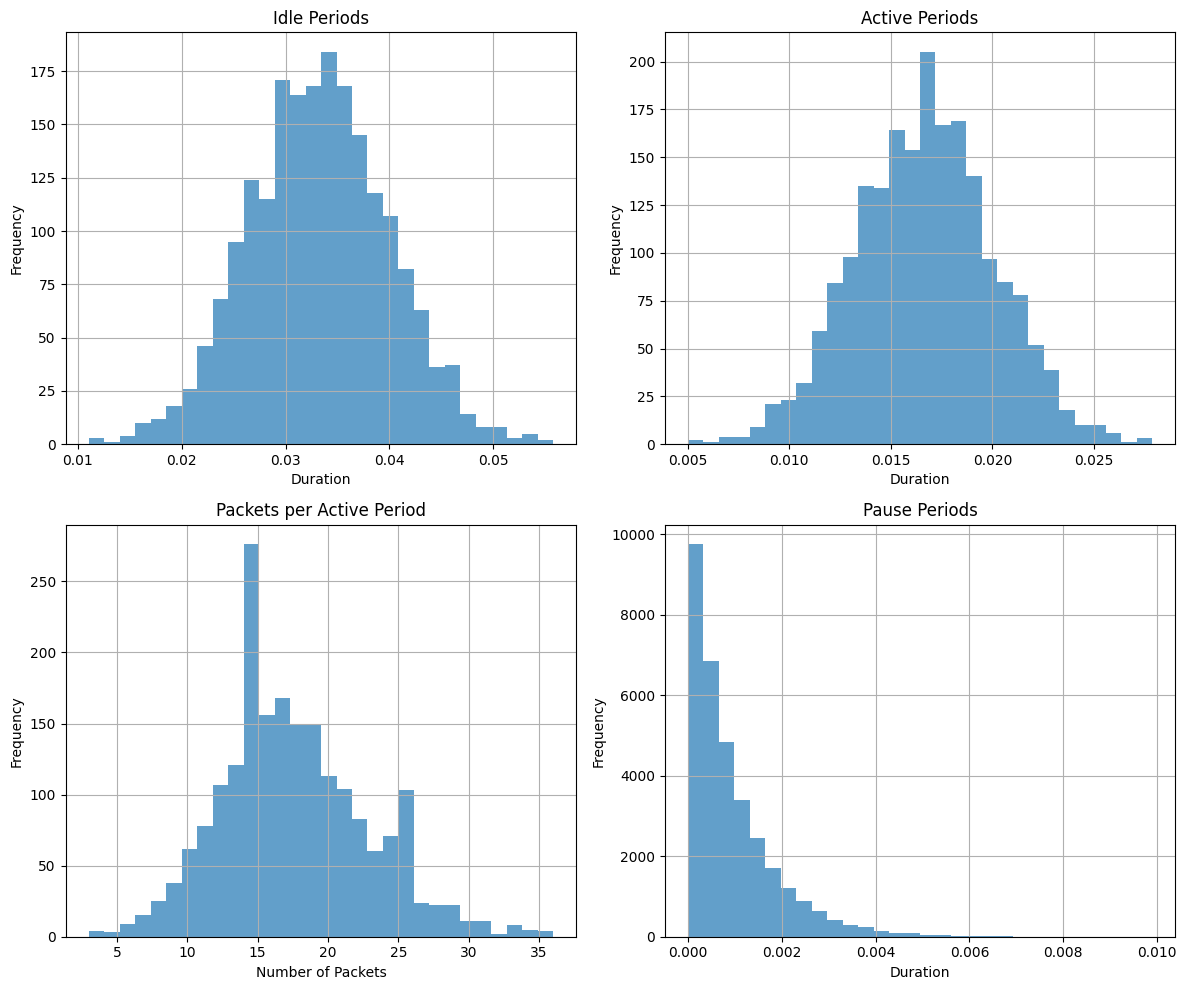

In [ ]:
import simpy
import random
import numpy as np
import matplotlib.pyplot as plt


class BurstyVideoSource:
    def __init__(self, env, name, out, sim_time):
        self.env = env
        self.name = name
        self.out = out
        self.sim_time = sim_time
        self.packets_sent = 0

        # Calculated parameters
        self.idle_mean = (2/3)*(1/20)  #Enter the value from your calculation Hint: active period is half of the idle period and sum is 1/20.
        self.idle_std = 0.2 * self.idle_mean  #20 percent of idle_mean
        self.active_mean = (1/3)*(1/20)  #Enter the value from your calculation Hint: active period is half of the idle period and sum is 1/20.
        self.active_std = 0.2 * self.active_mean  #20 percent of active_mean
        self.packet_size_mean = 300   # bytes given
        self.pause_mean = 0.0005   # from above

        self.idle_log = []
        self.active_log = []
        self.pause_log = []
        self.packets_per_active_period = []

        self.action = env.process(self.run())

    def run(self):
        while self.env.now < self.sim_time:
            # Idle period
            idle_duration = max(0, random.gauss(self.idle_mean, self.idle_std))
            idle_start = self.env.now
            idle_end = min(idle_start + idle_duration, self.sim_time)
            self.idle_log.append((idle_start, idle_end))
            yield self.env.timeout(idle_end - idle_start)

            if self.env.now >= self.sim_time:
                break

            # Active period
            active_duration = max(0, random.gauss(self.active_mean, self.active_std))
            active_start = self.env.now
            active_end = min(self.env.now + active_duration, self.sim_time)
            self.active_log.append((active_start, active_end))

            packet_count = 0

            while self.env.now < active_end:
                # Packet size from Poisson
                pkt_size = max(1, np.random.poisson(self.packet_size_mean))                
                
                # Send packet
                self.packets_sent += 1
                packet_count += 1

                packet = type("Packet", (), {})()
                packet.time = self.env.now
                packet.size = pkt_size
                packet.id = self.packets_sent
                packet.src = self.name

                if self.out:
                    self.out.put(packet)

                # Pause between packets from exponential
                pause = np.random.exponential(self.pause_mean)

                if self.env.now + pause > active_end:
                    yield self.env.timeout(active_end - self.env.now)
                    break

                self.pause_log.append(pause)
                yield self.env.timeout(pause)

            self.packets_per_active_period.append(packet_count)


# -----------------------------
# Run simulation
# -----------------------------
env = simpy.Environment()
sim_time = 100
src = BurstyVideoSource(env, "VideoSource", out=None, sim_time=sim_time)

env.run(until=sim_time)

# -----------------------------
# Convert logs to durations
# -----------------------------
idle_periods = [end - start for start, end in src.idle_log]
active_periods = [end - start for start, end in src.active_log]
packets_per_active_period = src.packets_per_active_period
pause_periods = src.pause_log

# -----------------------------
# Plot histograms
# -----------------------------
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.hist(idle_periods, bins=30, alpha=0.7)
plt.title("Idle Periods")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.hist(active_periods, bins=30, alpha=0.7)
plt.title("Active Periods")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(2, 2, 3)
plt.hist(packets_per_active_period, bins=30, alpha=0.7)
plt.title("Packets per Active Period")
plt.xlabel("Number of Packets")
plt.ylabel("Frequency")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.hist(pause_periods, bins=30, alpha=0.7)
plt.title("Pause Periods")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()

In [566]:
# -----------------------------
# Output statistics
# -----------------------------
total_bits_sent = src.packets_sent * src.packet_size_mean * 8
avg_bitrate = total_bits_sent / sim_time
avg_packet_size_bits = src.packet_size_mean * 8
total_idle_time = sum(idle_periods)
total_active_time = sum(active_periods)
idle_active_ratio = total_idle_time / total_active_time if total_active_time > 0 else float('inf')

print("Average Bitrate (b/s):", avg_bitrate)
print("Average Packet Size (bits):", avg_packet_size_bits)
print("Idle/Active Period Ratio calculated from simulation:", idle_active_ratio)
print("Packets Sent:", src.packets_sent)
print("Total Idle Time (s):", total_idle_time)
print("Total Active Time (s):", total_active_time)

print("Average Packets per Active Period:", np.mean(packets_per_active_period))

Average Bitrate (b/s): 843504.0
Average Packet Size (bits): 2400
Idle/Active Period Ratio calculated from simulation: 1.991725011031034
Packets Sent: 35146
Total Idle Time (s): 66.57446803055701
Total Active Time (s): 33.425531969442986
Average Packets per Active Period: 17.537924151696608
